In [1]:
# 3. CNN 이미지 분류 실습
# - 예제 데이터 : Fashion MNIST
# - CNN 기반 이미지 분류
# - 학습 결과 저장
# - 저장된 모델/스케일러/학습 이력 불러오기
# - 신규 데이터 예측
# - 학습결과 및 예측결과 시각화

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, auc
import joblib                                     # 파이썬 객체 저장을 위한 joblib

import tensorflow as tf                           # 딥러닝 프레임워크

from tensorflow.keras import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical

np.random.seed(42)
tf.random.set_seed(42)

In [3]:
# 1. 데이터셋 준비

# fashion mnist 데이터 가져오기
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

# 클래스 이름 정의
class_names = [
  'T-shirt/top',
  'Trouser',
  'Pullover',
  'Dress',
  'Coat',
  'Sandal',
  'Shirt',
  'Sneaker',
  'Bag',
  'Ankle boot'
]

# 데이터 shape 확인
print('X_train shape : ', X_train.shape)
print('X_test shape : ', X_test.shape)


29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
X_train shape :  (60000, 28, 28)
X_test shape :  (10000, 28, 28)


In [ ]:
# 2. 데이터 정규화

# 픽셀값 0~1 범위로 정규화
X_train = X_train / 255.0
X_test = X_test / 255.0

# CNN 입력 형태에 맞게 채널 차원을 Reshape      - Conv2D는 입력수가 4개(이미지수, 높이, 너비, 채널수)
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

In [5]:
# 3. 모델 정의
model = Sequential()

# 모델 신경망 생성(합성곱 층)
model.add(Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)))

# 풀링 층 추가
model.add(MaxPooling2D((2,2)))

# 두번째 층 추가
model.add(Conv2D(64, (3,3), activation='relu'))

# 두번째 풀링 층 추가
model.add(MaxPooling2D((2,2)))

# 1차원 벡터로 펼침
model.add(Flatten())

# 완전 연결층 추가
model.add(Dense(128, activation='relu'))

# 드롭아웃 추가
model.add(Dropout(0.3))

# 출력층 추가
model.add(Dense(10, activation='softmax'))


/home/pc/anaconda3/envs/ai/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
E0000 00:00:1787288102.697397   89182 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1787288102.741730   89182 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [6]:
# 4. 모델 컴파일 설정
model.compile(
  optimizer='adam',
  loss='sparse_categorical_crossentropy',
  metrics=['accuracy']
)

# 학습 조기 종료 설정
early_stop = EarlyStopping(
  monitor='val_loss',
  patience=5,
  restore_best_weights=True
)

In [7]:
# 5. 모델 학습
history = model.fit(
  X_train,               # 입력데이터 X
  y_train,                      # 정답데이터 y
  validation_split=0.2,           # 검증 20%
  epochs=20,                   # 전체 학습 수 100번
  batch_size=64,                # 한번에 도는 학습 1회 사이클 64번
  callbacks=[early_stop]        # 조기종료 콜백 정의
)

Epoch 1/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.7929 - loss: 0.5705 - val_accuracy: 0.8659 - val_loss: 0.3739
Epoch 2/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.8657 - loss: 0.3702 - val_accuracy: 0.8831 - val_loss: 0.3180
Epoch 3/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.8832 - loss: 0.3202 - val_accuracy: 0.8907 - val_loss: 0.2930
Epoch 4/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.8953 - loss: 0.2864 - val_accuracy: 0.8908 - val_loss: 0.2915
Epoch 5/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9033 - loss: 0.2614 - val_accuracy: 0.9007 - val_loss: 0.2707
Epoch 6/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9112 - loss: 0.2421 - val_accuracy: 0.9038 - val_loss: 0.2662
Epoch 7/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9171 - loss: 0.2248 - val_accuracy: 0.9056 - val_loss: 0.2645
Epoch 8/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9224 - loss: 0.2090 - val_accuracy: 0.

In [8]:
# ============================================
# 6. 성능 평가
# ============================================

test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)

# 결과 출력
print("테스트 손실: ", test_loss)
print("테스트 정확도: ", test_acc)

테스트 손실:  0.2796041667461395
테스트 정확도:  0.9054999947547913


In [10]:
# ============================================
# 7. 예측 확률 계산
# ============================================

# 테스트 데이터 예측 확률 계산
y_prob = model.predict(X_test)

# 최종 예측 클래스 계산
y_pred = np.argmax(y_prob, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [12]:
# ================================================
# 8. 학습 결과 저장
# ================================================

model.save("./model/cnn_fashion_mnist.h5")

# 모델 학습 결과 읽어오기
loaded_model = tf.keras.models.load_model("./model/cnn_fashion_mnist.h5")

In [15]:
# 9. 신규 데이터 예측/분류
# 학습하지 않은 데이터 이미지 5개 읽어오기
new_images = X_test[:5]

# 신규 이미지 예측
new_prob = loaded_model.predict(new_images)

# 최종 클래스 예측값 계산
new_pred = np.argmax(new_prob, axis=1)

# 예측결과 출력
for i in range(len(new_images)):
  print(f"{i + 1} 번 이미지 - 예측클래스 : {new_pred[i]} ({class_names[new_pred[i]]})")

print(f"실제값: {y_test[:5]}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1 번 이미지 - 예측클래스 : 9 (Ankle boot)
2 번 이미지 - 예측클래스 : 2 (Pullover)
3 번 이미지 - 예측클래스 : 1 (Trouser)
4 번 이미지 - 예측클래스 : 1 (Trouser)
5 번 이미지 - 예측클래스 : 6 (Shirt)
실제값: [9 2 1 1 6]


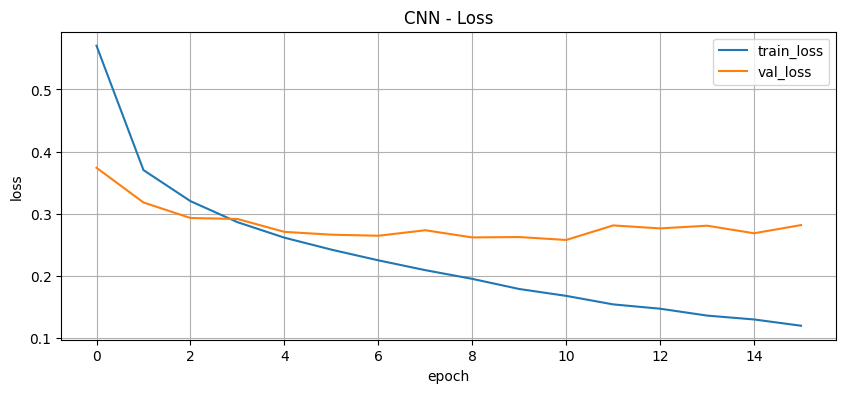

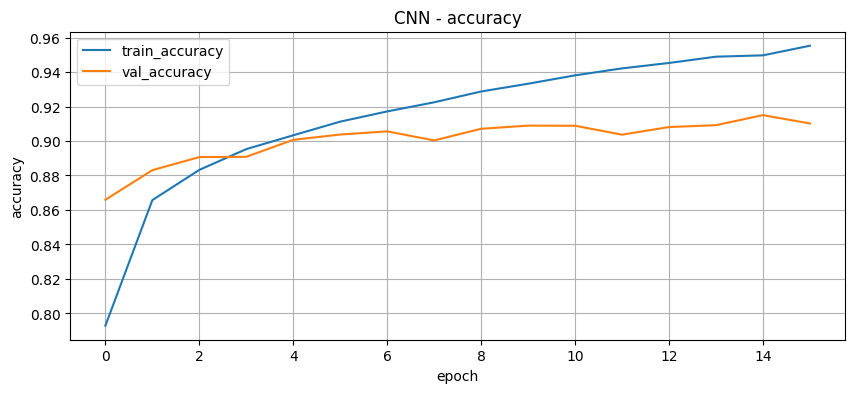

In [16]:
# ============================================
# 결과 시각화
# ============================================

# 학습 손실 그래프
plt.figure(figsize=(10,4))
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title('CNN - Loss')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.grid(True)

plt.show()

# 학습 정확도 그래프
plt.figure(figsize=(10,4))
plt.plot(history.history['accuracy'], label='train_accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.title('CNN - accuracy')
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.legend()
plt.grid(True)

plt.show()

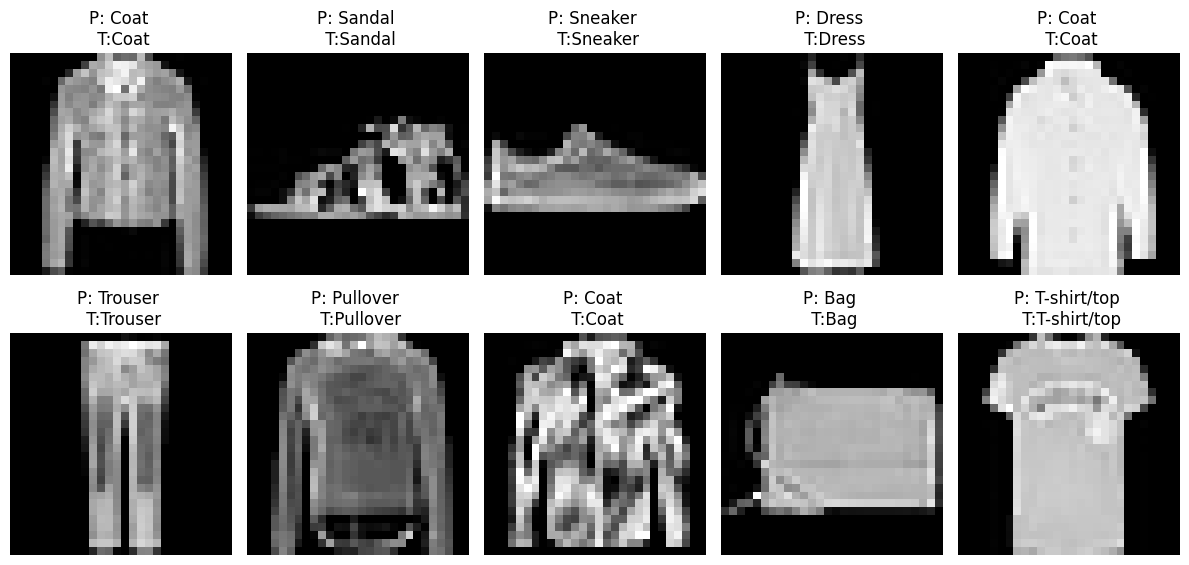

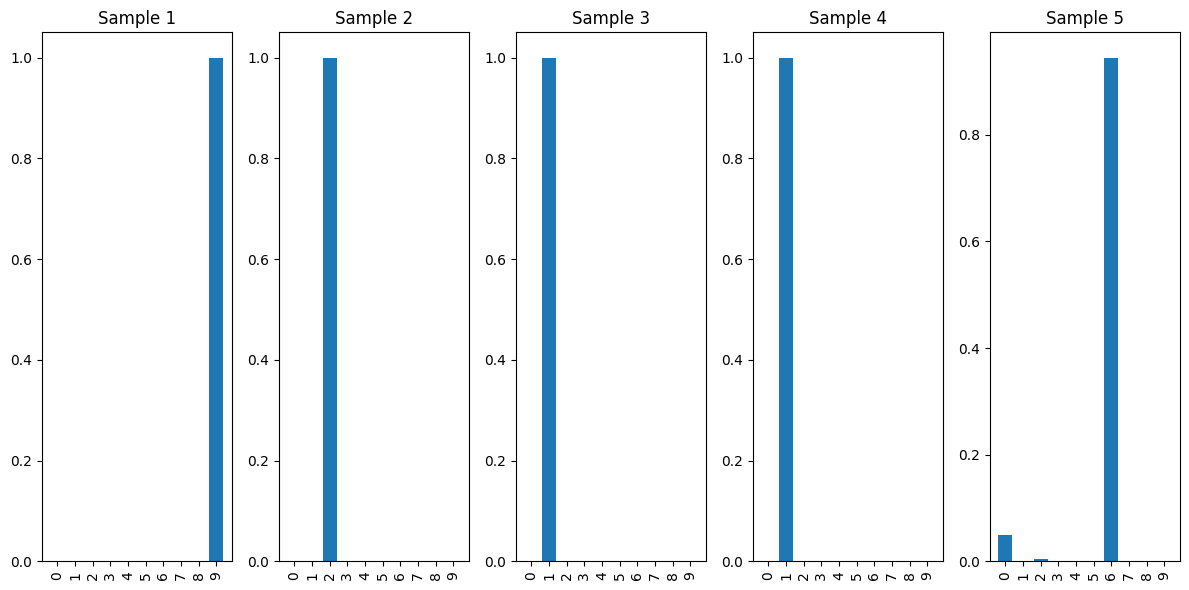

In [18]:
# 테스트 이미지(10개)와 예측 결과 시각화
plt.figure(figsize=(12,6))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(X_test[i + 10].reshape(28,28), cmap='gray')
    plt.title(f"P: {class_names[y_pred[i + 10]]} \n T:{class_names[y_test[i + 10]]}")
    plt.axis('off')

plt.tight_layout()
plt.show()

# 신규 이미지 5개에 대한 확률 분포 시각화
plt.figure(figsize=(12,6))
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.bar(range(10), new_prob[i])
    plt.title(f"Sample {i+1}")
    plt.xticks(range(10), rotation=90)

plt.tight_layout()
plt.show()